In [42]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from pylab import rcParams
rcParams['figure.figsize'] = 10, 6
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from pmdarima.arima import auto_arima

from sklearn.metrics import mean_squared_error, mean_absolute_error
import math


In [43]:
df = pd.read_csv('D:\SohamInternshipWork\datasets\stockdata.csv')

In [44]:
print(df.shape)
print(df.info())

(2306, 6)
<class 'pandas.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MSFT    2306 non-null   float64
 1   IBM     2306 non-null   float64
 2   SBUX    2306 non-null   float64
 3   AAPL    2306 non-null   float64
 4   GSPC    2306 non-null   float64
 5   Date    2306 non-null   str    
dtypes: float64(5), str(1)
memory usage: 108.2 KB
None


In [45]:
print(df.describe())

              MSFT          IBM         SBUX         AAPL         GSPC
count  2306.000000  2306.000000  2306.000000  2306.000000  2306.000000
mean     28.737785   136.239600    23.213089    54.719810  1459.999869
std       9.471737    37.376360    15.522634    34.645282   361.673516
min      12.630211    61.274273     3.284911    10.345740   676.530029
25%      22.582537   102.407469    10.792787    22.929971  1198.417481
50%      24.990737   143.833125    17.896952    49.327484  1402.370056
75%      33.873379   172.566340    35.305682    78.102594  1770.579986
max      56.146870   198.948796    63.098822   130.671320  2130.820068


In [46]:
df['Date'] = pd.to_datetime(df['Date'])

In [47]:
print(df.isna().sum())

MSFT    0
IBM     0
SBUX    0
AAPL    0
GSPC    0
Date    0
dtype: int64


In [48]:
data = df.set_index('Date')

In [49]:
data

,MSFT,IBM,SBUX,AAPL,GSPC
Date,,,,,
2007-01-03,23.950705,80.517962,16.149666,11.086612,1416.599976
2007-01-04,23.910599,81.378851,16.167992,11.332687,1418.339966
2007-01-05,23.774242,80.642129,16.099269,11.251984,1409.709961
2007-01-08,24.006852,81.867244,16.039710,11.307550,1412.839966
2007-01-09,24.030914,82.835742,15.970989,12.246870,1412.109985
...,...,...,...,...,...
2016-02-24,51.360001,132.800003,58.110001,96.099998,1929.800049
2016-02-25,52.099998,134.500000,58.750000,96.760002,1951.699951
2016-02-26,51.299999,132.029999,58.340000,96.910004,1948.050049


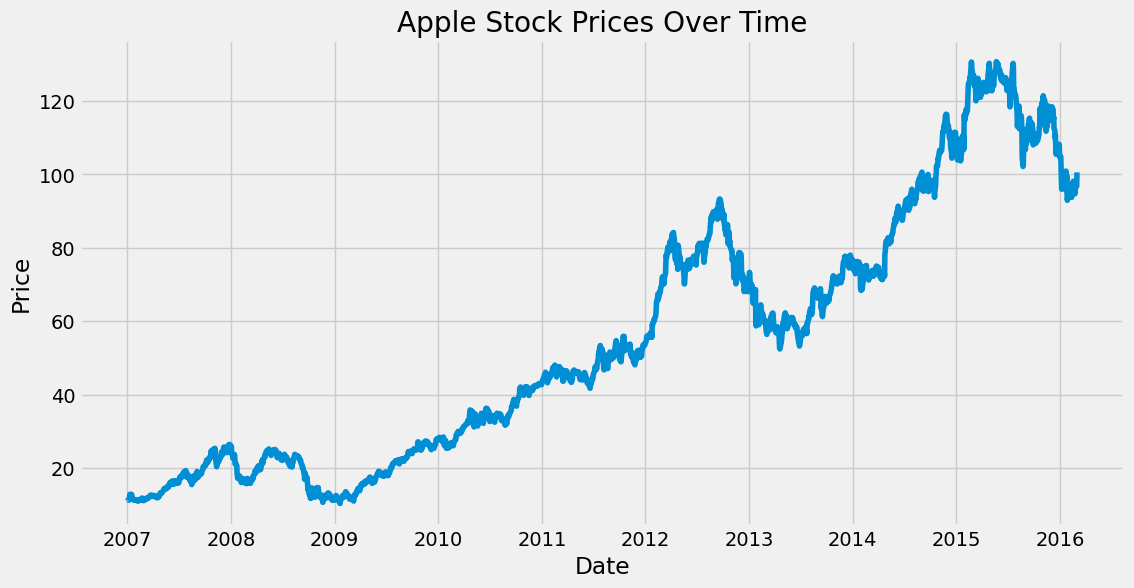

In [50]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data['AAPL'])

plt.title("Apple Stock Prices Over Time")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

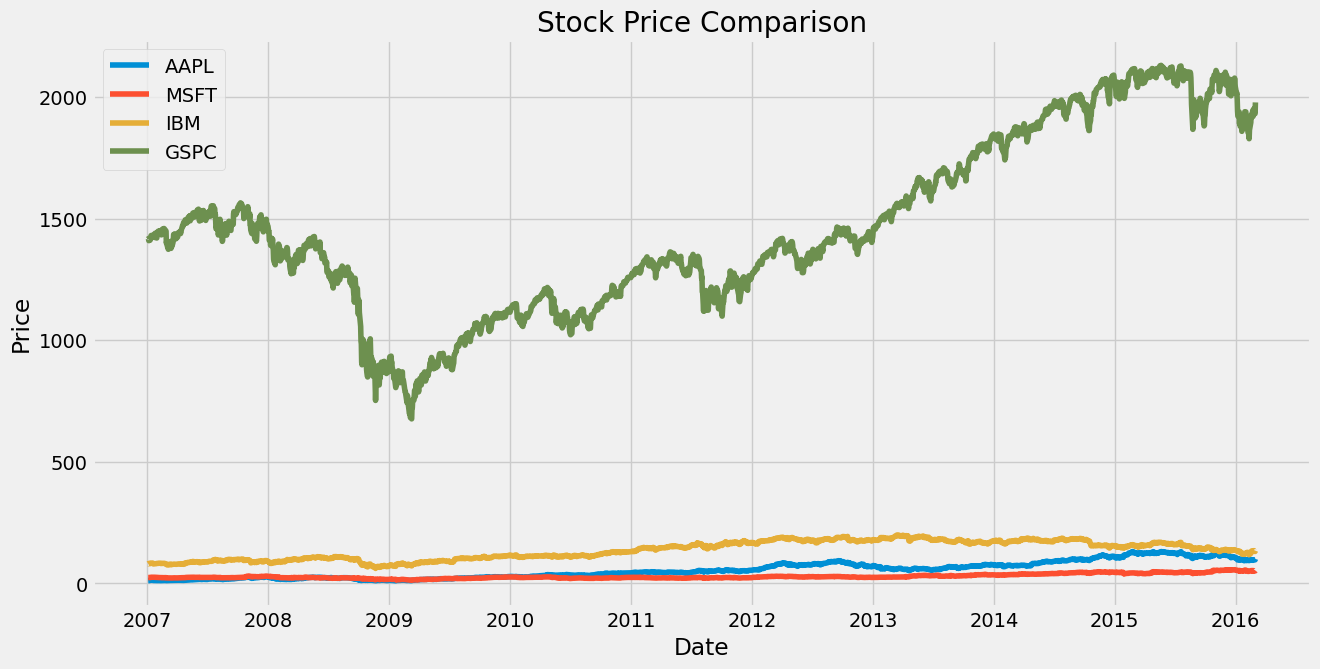

In [51]:
plt.figure(figsize=(14,7))

plt.plot(data.index, data['AAPL'], label='AAPL')

plt.plot(data.index, data['MSFT'], label='MSFT')

plt.plot(data.index, data['IBM'], label='IBM')

plt.plot(data.index, data['GSPC'], label='GSPC')

plt.legend()

plt.title("Stock Price Comparison")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

In [52]:
print(pd.infer_freq(data.index))

None


In [53]:
time_diffs = data.index.to_series().diff()
print(time_diffs.value_counts().head(10))

Date
1 days    1805
3 days     417
4 days      60
2 days      22
5 days       1
Name: count, dtype: int64


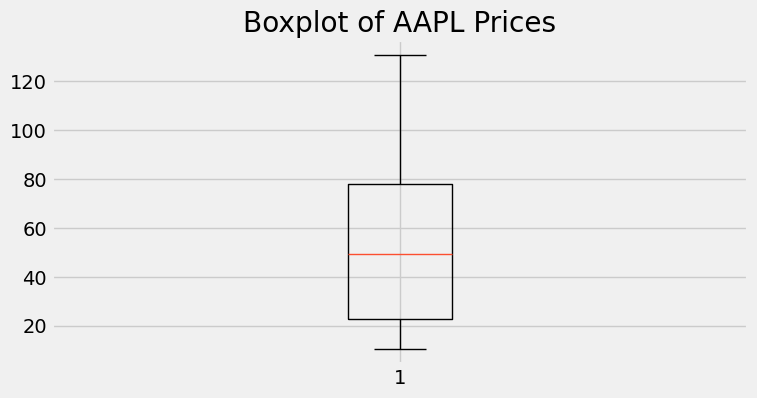

In [54]:
plt.figure(figsize=(8,4))

plt.boxplot(data['AAPL'],label='AAPL')

plt.title("Boxplot of AAPL Prices")

plt.show()

<Axes: ylabel='Density'>

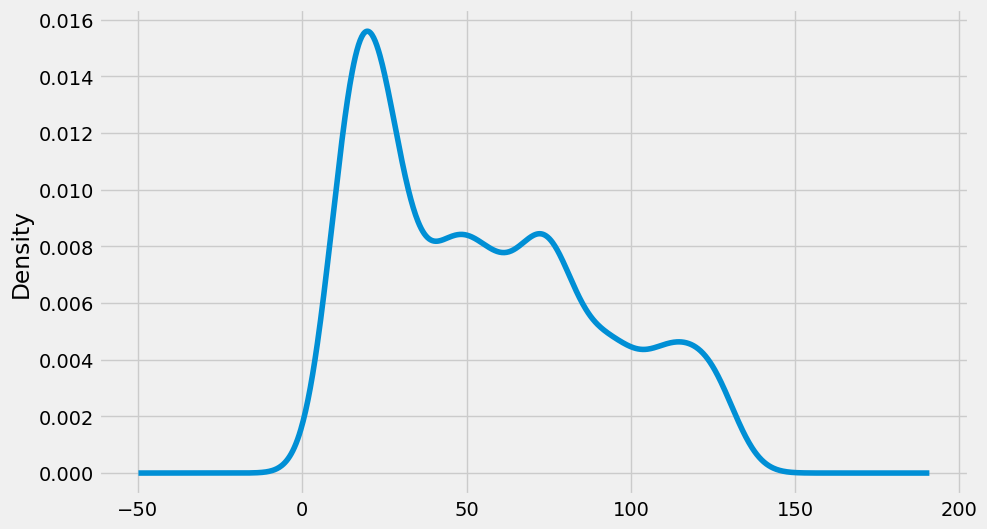

In [55]:
data['AAPL'].plot(kind='kde')

<Figure size 1000x600 with 0 Axes>

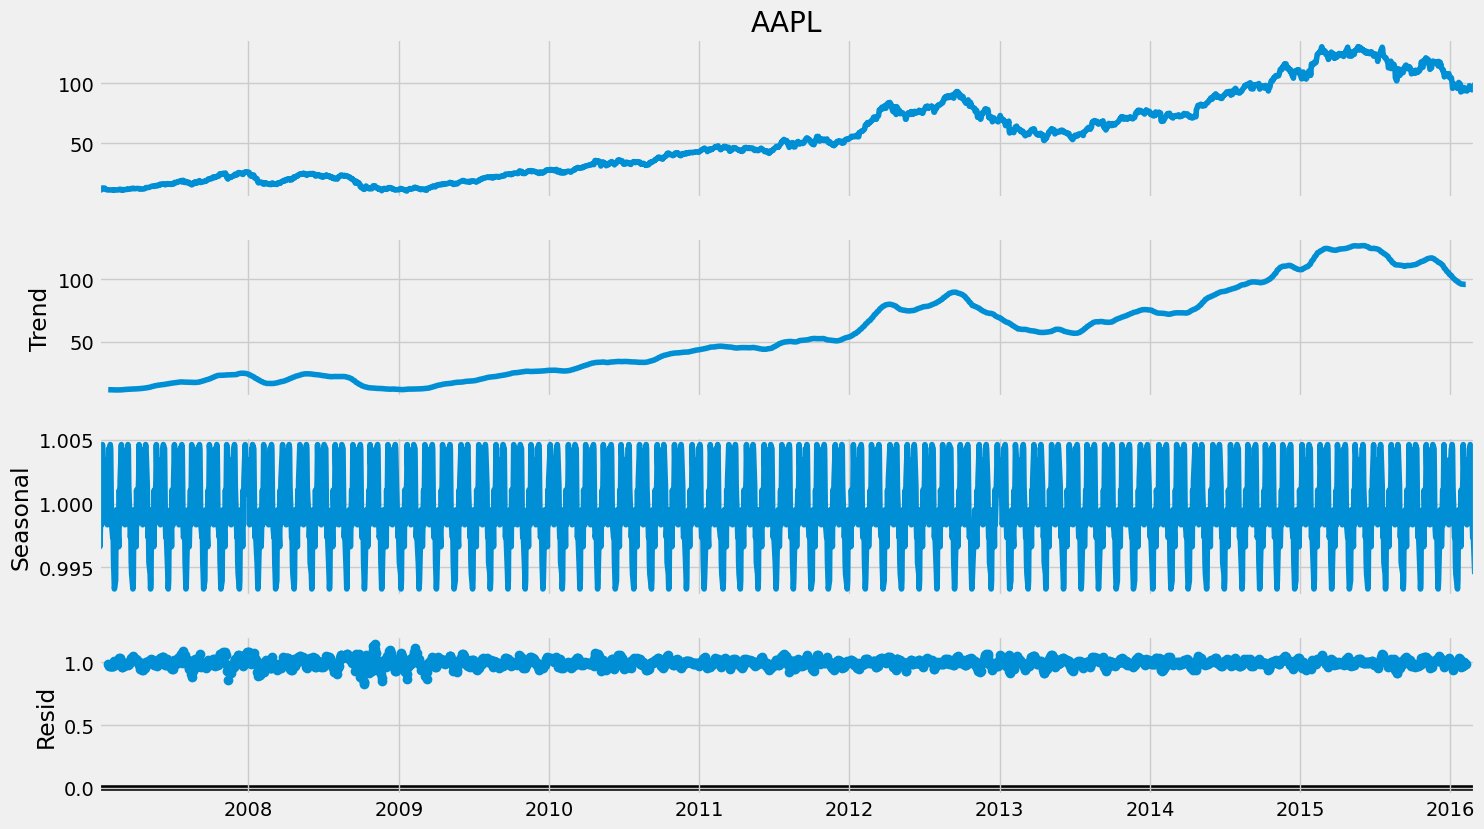

In [56]:
result = seasonal_decompose(data['AAPL'],model='multiplicative',period=30)
fig = plt.figure()
fig = result.plot()
fig.set_size_inches(16,9)

In [57]:
adf_test  = adfuller(data['AAPL'])
print(f"p_value:{adf_test[1]}")

p_value:0.8459565003027989


Transform the data into log data 

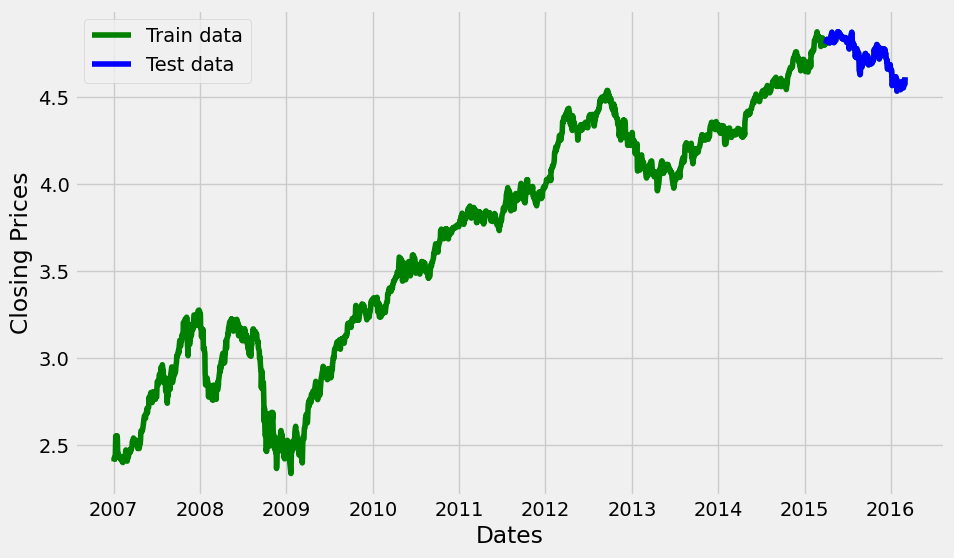

In [58]:
data_log = np.log(data['AAPL'])
train_data, test_data = data_log[3:int(len(data_log)*0.9)], data_log[int(len(data_log)*0.9):]
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(data_log, 'green', label='Train data')
plt.plot(test_data, 'blue', label='Test data')
plt.legend()

<Axes: xlabel='Date'>

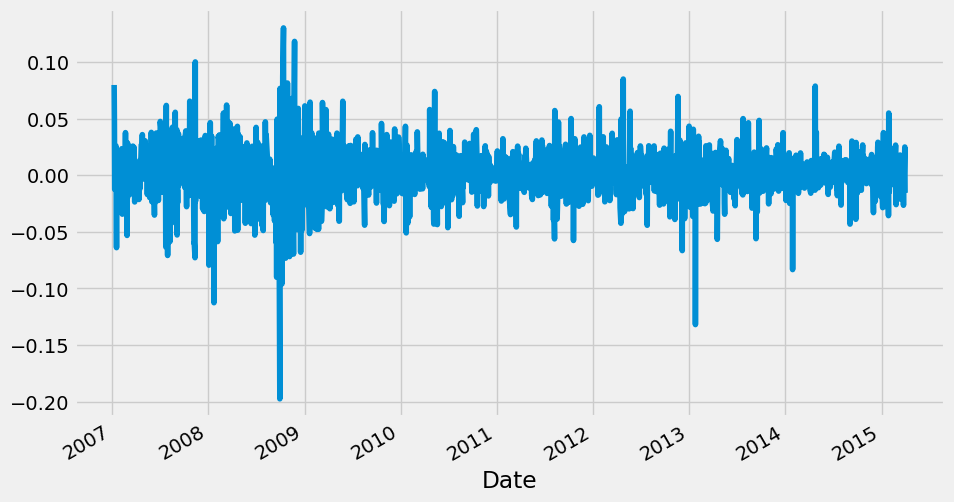

In [59]:
train_data_diff = train_data.diff().dropna()
train_data_diff.plot()

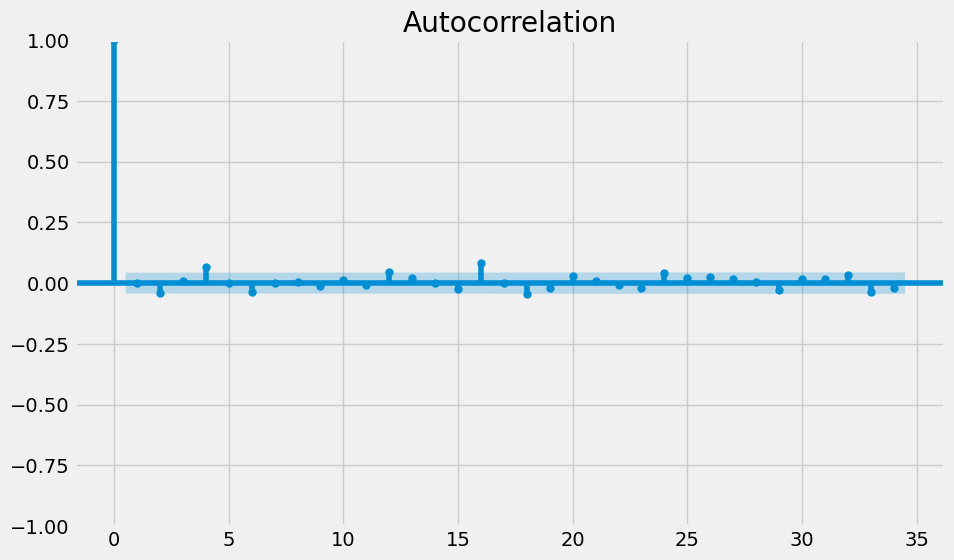

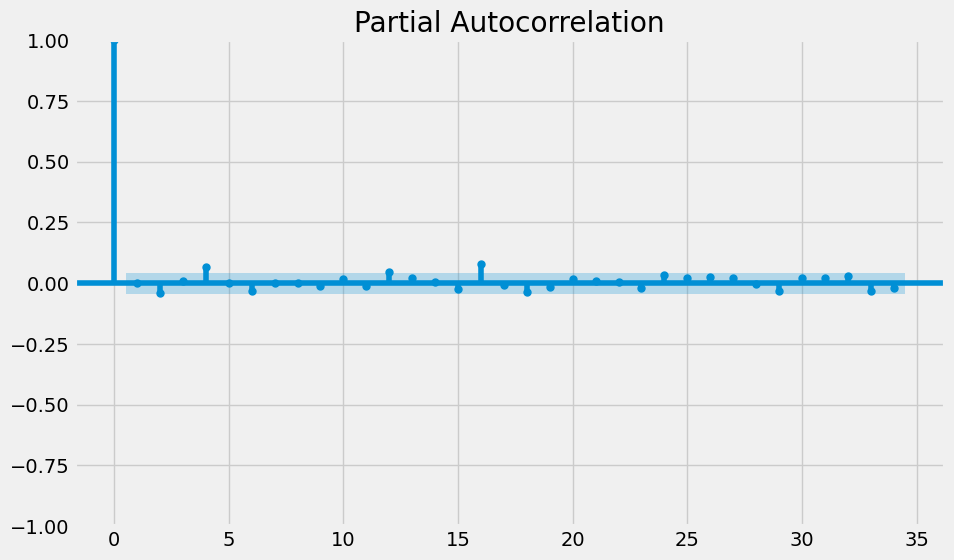

In [60]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
acf_diff = plot_acf(train_data_diff)
pacf_diff = plot_pacf(train_data_diff)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-9977.828, Time=0.90 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-9975.828, Time=0.23 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-9975.828, Time=0.60 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-9974.046, Time=0.20 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-9974.000, Time=0.66 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 2.674 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2072
Model:               SARIMAX(0, 1, 0)   Log Likelihood                4990.914
Date:                Tue, 26 May 2026   AIC                          -9977.828
Time:                        09:51:19   BIC                          -9966.556
Sample:                             0   HQIC                         -9973.696
                               - 2072                                  

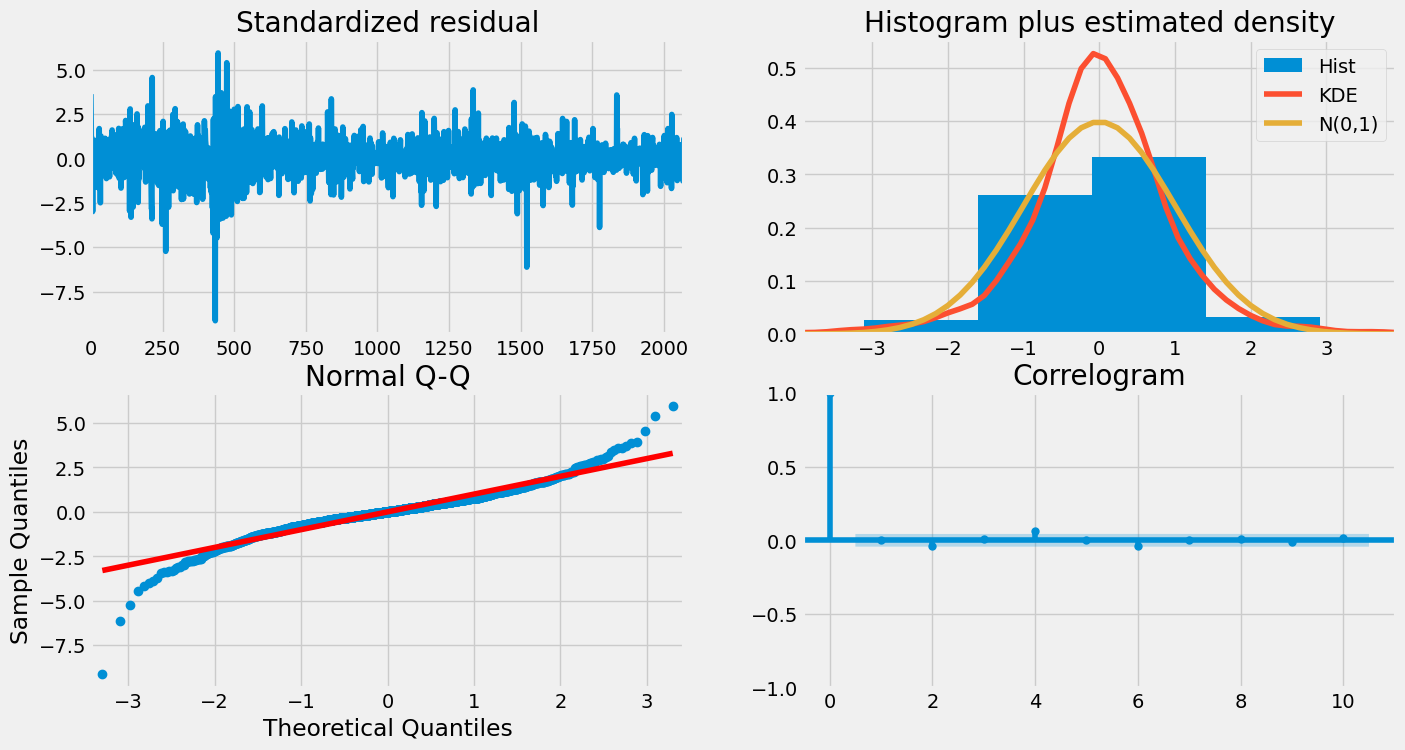

In [61]:
model_autoARIMA = auto_arima(train_data, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

In [62]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_data,order=(0,1,0))
fitted = model.fit()
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 2072
Model:                 ARIMA(0, 1, 0)   Log Likelihood                4988.023
Date:                Tue, 26 May 2026   AIC                          -9974.046
Time:                        09:51:20   BIC                          -9968.410
Sample:                             0   HQIC                         -9971.980
                               - 2072                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0005   7.08e-06     66.897      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              4033.45
Prob(Q):                              0.98   Pr

In [63]:
history = list(train_data)

predictions = []

for t in range(len(test_data)):

    model = ARIMA(history, order=(0,1,0))

    fitted = model.fit()

    forecast = fitted.forecast()

    yhat = forecast[0]

    predictions.append(yhat)

    actual = test_data.iloc[t]

    history.append(actual)

In [64]:
predictions_series = pd.Series(predictions, index=test_data.index)
trained_prices = np.exp(train_data)
actual_prices = np.exp(test_data)
predicted_prices = np.exp(predictions_series)

In [65]:
mse  = mean_squared_error(test_data, predictions)
mae  = mean_absolute_error(test_data, predictions)
rmse = math.sqrt(mse)
mape = np.mean(
    np.abs(
        (actual_prices - predicted_prices) / actual_prices
    )
) * 100

In [66]:
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MSE  : 0.000315
MAE  : 0.013092
RMSE : 0.017736
MAPE : 1.31%


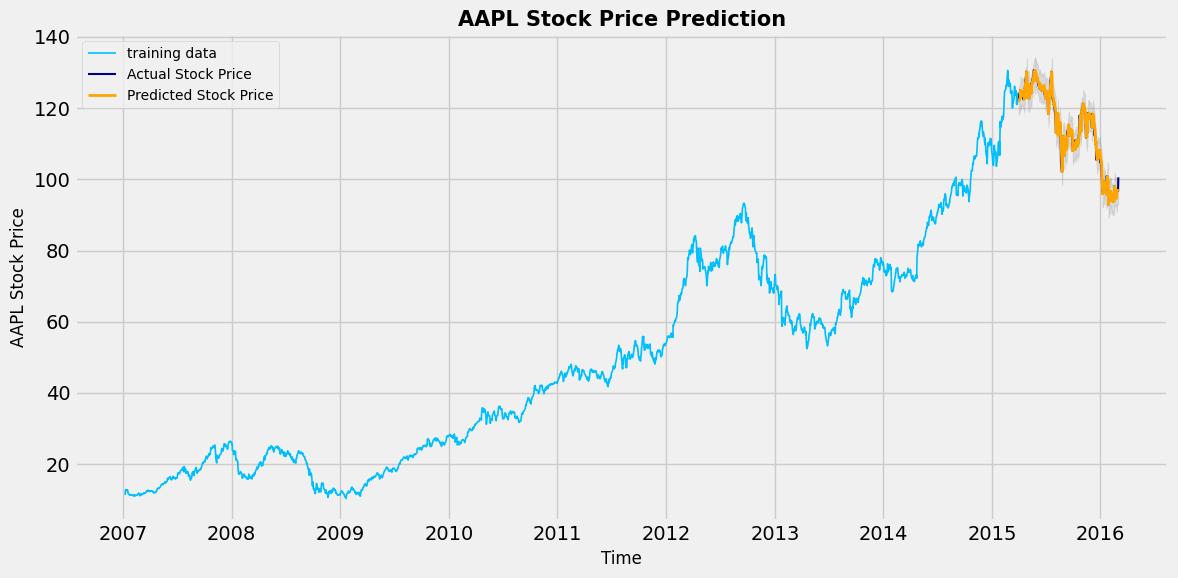

In [67]:
std_err = np.std(np.array(predicted_prices) - np.array(actual_prices))
 
fig, ax = plt.subplots(figsize=(12, 6))
 
# Training data — cyan
ax.plot(trained_prices, color='deepskyblue', linewidth=1.2, label='training data')
 
# Actual test prices — dark blue
ax.plot(actual_prices, color='navy', linewidth=1.5, label='Actual Stock Price')
 
# Predicted prices — orange
ax.plot(predicted_prices, color='orange', linewidth=2, label='Predicted Stock Price')
 
# 95% confidence interval shading
ax.fill_between(
    predicted_prices.index,
    predicted_prices - 1.96 * std_err,
    predicted_prices + 1.96 * std_err,
    color='gray', alpha=0.2
)
 
ax.set_title('AAPL Stock Price Prediction', fontsize=15, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('AAPL Stock Price', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

In [68]:
def create_lag_features(series, n_lags=10):
    df_feat = pd.DataFrame({'y': series})
    for lag in range(1, n_lags + 1):
        df_feat[f'lag_{lag}'] = df_feat['y'].shift(lag)
    df_feat.dropna(inplace=True)
    X = df_feat.drop('y', axis=1).values
    y = df_feat['y'].values
    return X, y, df_feat.index
 
N_LAGS = 10

In [71]:
X_all, y_all, idx_all = create_lag_features(data_log, n_lags=N_LAGS)

In [72]:
split_idx = int(len(X_all) * 0.9)
X_train_xgb, X_test_xgb = X_all[:split_idx], X_all[split_idx:]
y_train_xgb, y_test_xgb = y_all[:split_idx], y_all[split_idx:]
idx_test_xgb = idx_all[split_idx:]

In [96]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    random_state=42,
    verbosity=0,
    eval_metric='rmse'  # <-- Moved here
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)]
)


[0]	validation_0-rmse:0.76850
[1]	validation_0-rmse:0.54480
[2]	validation_0-rmse:0.38539
[3]	validation_0-rmse:0.27676
[4]	validation_0-rmse:0.19721
[5]	validation_0-rmse:0.14011
[6]	validation_0-rmse:0.10067
[7]	validation_0-rmse:0.07284
[8]	validation_0-rmse:0.05372
[9]	validation_0-rmse:0.04109
[10]	validation_0-rmse:0.03274
[11]	validation_0-rmse:0.02762
[12]	validation_0-rmse:0.02479
[13]	validation_0-rmse:0.02360
[14]	validation_0-rmse:0.02297
[15]	validation_0-rmse:0.02251
[16]	validation_0-rmse:0.02237
[17]	validation_0-rmse:0.02231
[18]	validation_0-rmse:0.02228
[19]	validation_0-rmse:0.02221
[20]	validation_0-rmse:0.02221
[21]	validation_0-rmse:0.02221
[22]	validation_0-rmse:0.02221
[23]	validation_0-rmse:0.02221
[24]	validation_0-rmse:0.02221
[25]	validation_0-rmse:0.02221
[26]	validation_0-rmse:0.02222
[27]	validation_0-rmse:0.02222
[28]	validation_0-rmse:0.02222
[29]	validation_0-rmse:0.02222
[30]	validation_0-rmse:0.02196
[31]	validation_0-rmse:0.02196
[32]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [77]:
xgb_predictions = xgb_model.predict(X_test_xgb)
xgb_series = pd.Series(xgb_predictions, index=idx_test_xgb)
y_test_xgb_series = pd.Series(y_test_xgb, index=idx_test_xgb)

In [78]:
xgb_mse  = mean_squared_error(y_test_xgb, xgb_predictions)
xgb_mae  = mean_absolute_error(y_test_xgb, xgb_predictions)
xgb_rmse = math.sqrt(xgb_mse)
print("=== XGBoost ===")
print(f"MSE  : {xgb_mse:.6f}")
print(f"MAE  : {xgb_mae:.6f}")
print(f"RMSE : {xgb_rmse:.6f}")

=== XGBoost ===
MSE  : 0.000506
MAE  : 0.017601
RMSE : 0.022491


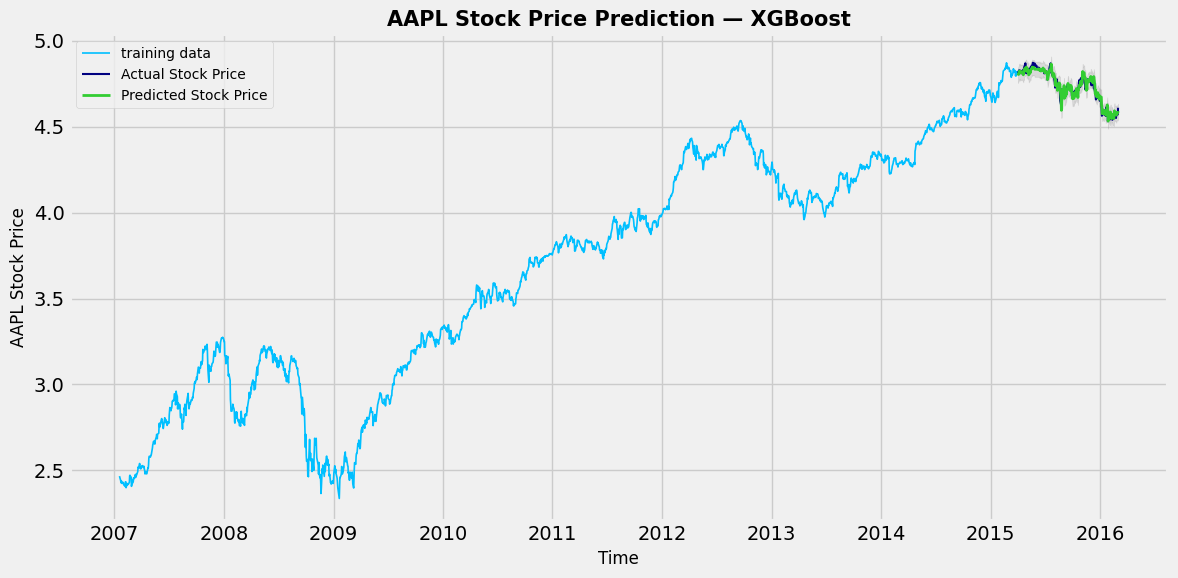

In [87]:
xgb_train_series = pd.Series(y_train_xgb, index=idx_all[:split_idx])
std_err_xgb = np.std(xgb_predictions - y_test_xgb)
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(xgb_train_series, color='deepskyblue', linewidth=1.2, label='training data')
ax.plot(y_test_xgb_series, color='navy', linewidth=1.5, label='Actual Stock Price')
ax.plot(xgb_series, color='limegreen', linewidth=2, label='Predicted Stock Price')
ax.fill_between(
    xgb_series.index,
    xgb_series - 1.96 * std_err_xgb,
    xgb_series + 1.96 * std_err_xgb,
    color='gray', alpha=0.2
)
ax.set_title('AAPL Stock Price Prediction — XGBoost', fontsize=15, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('AAPL Stock Price', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

FB Prophet 

In [82]:
from prophet import Prophet
prophet_df = pd.DataFrame({
    'ds': data_log.index,
    'y' : data_log.values
}).reset_index(drop=True)
 
# Use the same 90/10 split
split_n = int(len(prophet_df) * 0.9)
prophet_train = prophet_df.iloc[:split_n]
prophet_test  = prophet_df.iloc[split_n:]
 
# %%
prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

10:01:59 - cmdstanpy - INFO - Chain [1] start processing
10:02:03 - cmdstanpy - INFO - Chain [1] done processing


In [83]:
future = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='B')  # 'B' = business days
prophet_forecast = prophet_model.predict(future)

In [84]:
prophet_pred = prophet_forecast.tail(len(prophet_test))[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
prophet_pred.set_index('ds', inplace=True)
prophet_pred.index = pd.to_datetime(prophet_pred.index)
 
prophet_actual_index = pd.to_datetime(prophet_test['ds'].values)
prophet_actual_series = pd.Series(prophet_test['y'].values, index=prophet_actual_index)
prophet_pred_series   = pd.Series(prophet_pred['yhat'].values, index=prophet_actual_index)
prophet_lower_series  = pd.Series(prophet_pred['yhat_lower'].values, index=prophet_actual_index)
prophet_upper_series  = pd.Series(prophet_pred['yhat_upper'].values, index=prophet_actual_index)

In [85]:
prophet_mse  = mean_squared_error(prophet_actual_series, prophet_pred_series)
prophet_mae  = mean_absolute_error(prophet_actual_series, prophet_pred_series)
prophet_rmse = math.sqrt(prophet_mse)
print("=== FB Prophet ===")
print(f"MSE  : {prophet_mse:.6f}")
print(f"MAE  : {prophet_mae:.6f}")
print(f"RMSE : {prophet_rmse:.6f}")

=== FB Prophet ===
MSE  : 0.121777
MAE  : 0.290629
RMSE : 0.348966


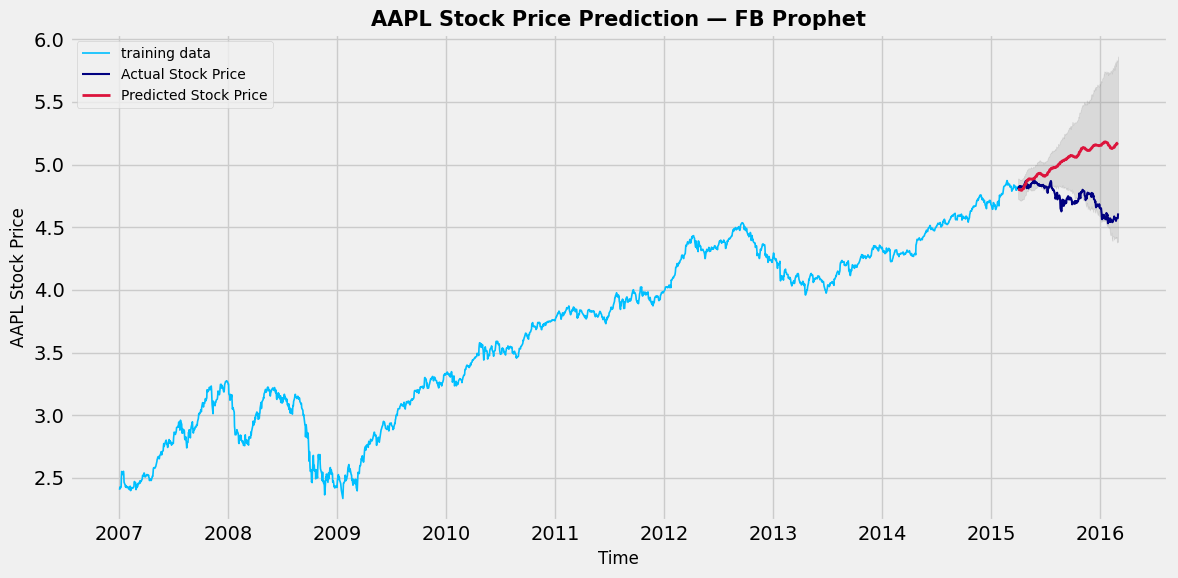

In [88]:
prophet_train_series = pd.Series(
    prophet_train['y'].values,
    index=pd.to_datetime(prophet_train['ds'].values)
)
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(prophet_train_series, color='deepskyblue', linewidth=1.2, label='training data')
ax.plot(prophet_actual_series, color='navy', linewidth=1.5, label='Actual Stock Price')
ax.plot(prophet_pred_series, color='crimson', linewidth=2, label='Predicted Stock Price')
ax.fill_between(
    prophet_actual_index,
    prophet_lower_series,
    prophet_upper_series,
    color='gray', alpha=0.2
)
ax.set_title('AAPL Stock Price Prediction — FB Prophet', fontsize=15, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('AAPL Stock Price', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

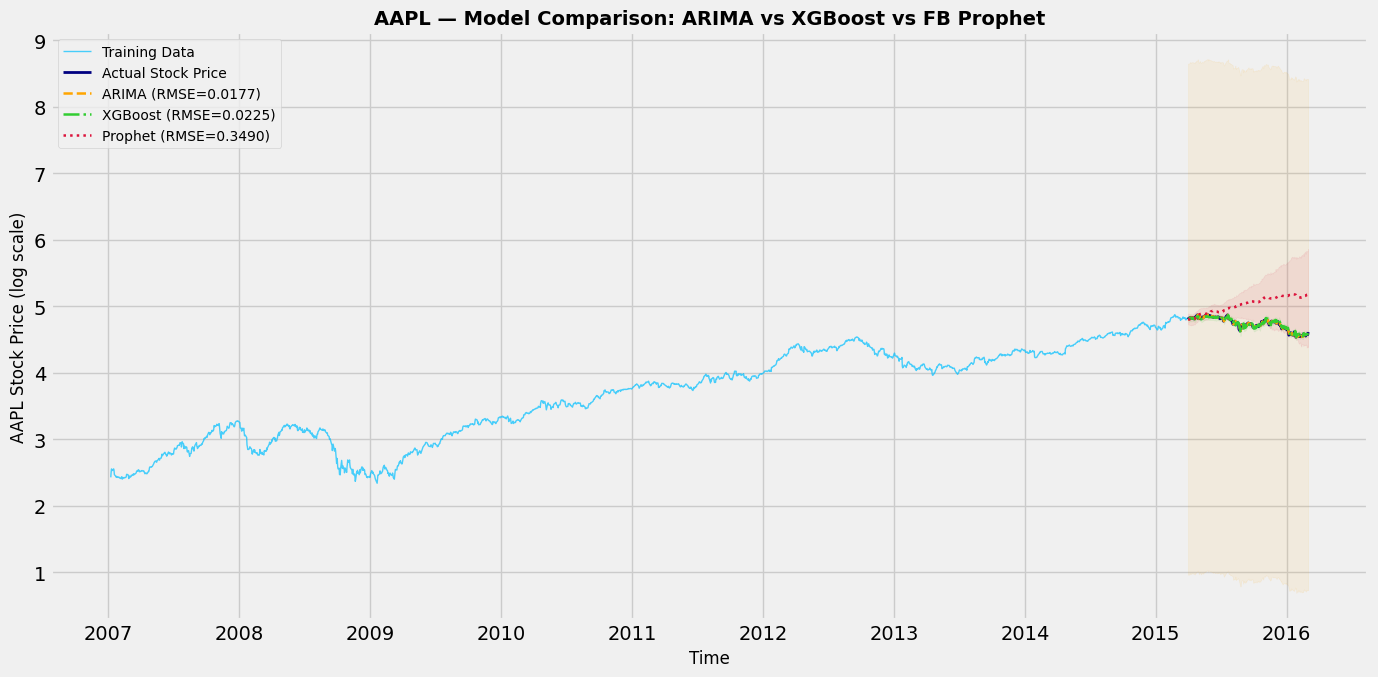

In [93]:
#ARIMA Plots
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(train_data, color='deepskyblue', linewidth=1.0, alpha=0.7, label='Training Data')
ax.plot(test_data, color='navy', linewidth=2.0, label='Actual Stock Price')
rmse_value = np.sqrt(mean_squared_error(test_data, predictions_series)) # Calculate your RMSE
ax.plot(predictions_series, color='orange', linewidth=1.8, linestyle='--', label=f'ARIMA (RMSE={rmse_value:.4f})')
ax.plot(xgb_series, color='limegreen', linewidth=1.8, linestyle='-.', label=f'XGBoost (RMSE={xgb_rmse:.4f})')
ax.plot(prophet_pred_series, color='crimson', linewidth=1.8, linestyle=':', label=f'Prophet (RMSE={prophet_rmse:.4f})')
ax.fill_between(
    predictions_series.index,
    predictions_series - 1.96 * std_err,
    predictions_series + 1.96 * std_err,
    color='orange', alpha=0.08
)
ax.fill_between(
    xgb_series.index,
    xgb_series - 1.96 * std_err_xgb,
    xgb_series + 1.96 * std_err_xgb,
    color='limegreen', alpha=0.08
)
ax.fill_between(
    prophet_actual_index,
    prophet_lower_series,
    prophet_upper_series,
    color='crimson', alpha=0.08
)
 
ax.set_title('AAPL — Model Comparison: ARIMA vs XGBoost vs FB Prophet',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('AAPL Stock Price (log scale)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


In [94]:
metrics_df = pd.DataFrame({
    'Model': ['ARIMA', 'XGBoost', 'FB Prophet'],
    'MSE'  : [mse,    xgb_mse,    prophet_mse],
    'MAE'  : [mae,    xgb_mae,    prophet_mae],
    'RMSE' : [rmse,   xgb_rmse,   prophet_rmse],
})
metrics_df.set_index('Model', inplace=True)
print(metrics_df.to_string())

                 MSE       MAE      RMSE
Model                                   
ARIMA       0.000315  0.013092  0.017736
XGBoost     0.000506  0.017601  0.022491
FB Prophet  0.121777  0.290629  0.348966


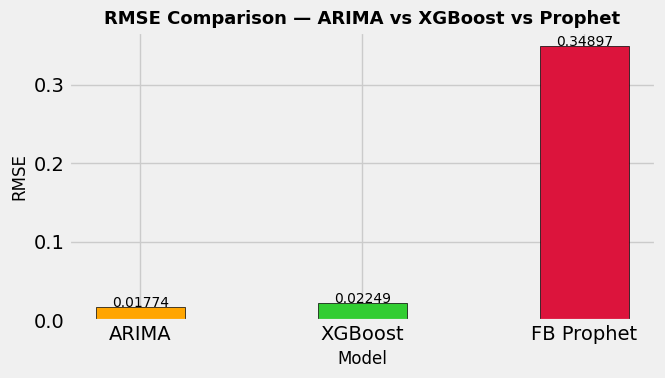

In [95]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['orange', 'limegreen', 'crimson']
ax.bar(metrics_df.index, metrics_df['RMSE'], color=colors, edgecolor='black', width=0.4)
ax.set_title('RMSE Comparison — ARIMA vs XGBoost vs Prophet', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
for i, (model, row) in enumerate(metrics_df.iterrows()):
    ax.text(i, row['RMSE'] + 0.0001, f"{row['RMSE']:.5f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()